# Phase 10: Synapse Arbitrator Validation
Walk-Forward Testing (2020-2024) on Google Colab

**Run all cells in order (Runtime > Run all)**

In [1]:
# Cell 1: Setup
!pip install -q --upgrade yfinance stockstats
!pip install -q torch pandas numpy scipy

import numpy as np
import pandas as pd
import yfinance as yf
import torch
import torch.nn as nn
from scipy.special import softmax
import warnings
warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"✓ Setup complete. Device: {device}, yfinance: {yf.__version__}")

✓ Setup complete. Device: cuda, yfinance: 0.2.66


In [2]:
# Cell 2: Configuration
TICKERS = ["AAPL", "MSFT", "GOOGL", "AMZN", "META", "NVDA", "JPM", "V", "JNJ", "WMT"]
WINDOWS = [
    {"name": "W1", "train": ("2020-01-01", "2021-06-30"), "test": ("2022-01-01", "2022-06-30")},
    {"name": "W2", "train": ("2021-01-01", "2022-06-30"), "test": ("2023-01-01", "2023-06-30")},
    {"name": "W3", "train": ("2022-01-01", "2023-06-30"), "test": ("2024-01-01", "2024-06-30")},
]
INITIAL_CAPITAL = 1_000_000
TRAIN_EPOCHS = 30
print(f"Tickers: {len(TICKERS)}, Windows: {len(WINDOWS)}")

Tickers: 10, Windows: 3


In [3]:
# Cell 3: Download Data + Feature Engineering (Combined)
from stockstats import StockDataFrame

print("Downloading data...")
df_list = []
for tic in TICKERS:
    try:
        data = yf.download(tic, start="2020-01-01", end="2024-12-31", progress=False, auto_adjust=False)
        if data.empty:
            continue
        if isinstance(data.columns, pd.MultiIndex):
            data.columns = [col[0] for col in data.columns]
        data = data.reset_index()
        data['tic'] = tic
        data = data.rename(columns={'Date': 'date', 'Open': 'open', 'High': 'high', 'Low': 'low', 'Close': 'close', 'Adj Close': 'adj_close', 'Volume': 'volume'})
        if 'adj_close' not in data.columns:
            data['adj_close'] = data['close']
        data = data[['date', 'open', 'high', 'low', 'close', 'adj_close', 'volume', 'tic']]
        df_list.append(data)
        print(f"  ✓ {tic}: {len(data)} rows")
    except Exception as e:
        print(f"  ✗ {tic}: {e}")

df = pd.concat(df_list, ignore_index=True)
df['date'] = pd.to_datetime(df['date'])
print(f"\nDownloaded: {len(df)} rows, {df['tic'].nunique()} tickers")

# Add technical indicators
print("\nAdding technical indicators...")
result = []
for tic in df['tic'].unique():
    tic_df = df[df['tic'] == tic].copy().sort_values('date').reset_index(drop=True)
    stock = StockDataFrame.retype(tic_df[['date', 'open', 'high', 'low', 'close', 'volume']].copy())
    tic_df['macd'] = stock['macd'].values
    tic_df['rsi_14'] = stock['rsi_14'].values
    result.append(tic_df)

df = pd.concat(result, ignore_index=True)
df['macd'] = df.groupby('tic')['macd'].transform(lambda x: x.ffill().bfill())
df['rsi_14'] = df.groupby('tic')['rsi_14'].transform(lambda x: x.ffill().bfill())
df = df.dropna()
print(f"✅ Final dataset: {len(df)} rows")
df.head()

  ✓ AAPL: 1257 rows
  ✓ MSFT: 1257 rows
  ✓ GOOGL: 1257 rows
  ✓ AMZN: 1257 rows
  ✓ META: 1257 rows
  ✓ NVDA: 1257 rows
  ✓ JPM: 1257 rows
  ✓ V: 1257 rows
  ✓ JNJ: 1257 rows
  ✓ WMT: 1257 rows

Downloaded: 12570 rows, 10 tickers

Adding technical indicators...
✅ Final dataset: 12570 rows


,date,open,high,low,close,adj_close,volume,tic,macd,rsi_14
0,2020-01-02,74.059998,75.150002,73.797501,75.087502,72.468246,135480400,AAPL,0.000000,0.000000
1,2020-01-03,74.287498,75.144997,74.125000,74.357498,71.763733,146322800,AAPL,-0.016378,0.000000
2,2020-01-06,73.447502,74.989998,73.187500,74.949997,72.335548,118387200,AAPL,-0.002496,46.640262
3,2020-01-07,74.959999,75.224998,74.370003,74.597504,71.995354,108872000,AAPL,-0.008847,35.909731
4,2020-01-08,74.290001,76.110001,74.290001,75.797501,73.153503,132079200,AAPL,0.035638,65.234063


In [4]:
# Cell 4: Trading Environment
class TradingEnv:
    def __init__(self, df, initial_capital=1_000_000):
        self.df = df.sort_values(['date', 'tic']).reset_index(drop=True)
        self.dates = sorted(df['date'].unique())
        self.tickers = sorted(df['tic'].unique())
        self.n_stocks = len(self.tickers)
        self.initial_capital = initial_capital
        self.state_dim = 1 + self.n_stocks * 3  # cash + (price, macd, rsi) per stock
        self.action_dim = self.n_stocks
        
    def reset(self):
        self.day_idx = 0
        self.cash = self.initial_capital
        self.holdings = np.zeros(self.n_stocks)
        self.portfolio_values = [self.initial_capital]
        return self._get_state()
    
    def _get_state(self):
        day = self.dates[self.day_idx]
        day_data = self.df[self.df['date'] == day]
        features = [self.cash / self.initial_capital]
        prices = []
        for tic in self.tickers:
            row = day_data[day_data['tic'] == tic]
            if len(row) > 0:
                prices.append(row['close'].values[0])
                features.extend([row['close'].values[0]/100, row['macd'].values[0], row['rsi_14'].values[0]/100])
            else:
                prices.append(0)
                features.extend([0, 0, 0.5])
        self.current_prices = np.array(prices)
        return np.array(features, dtype=np.float32)
    
    def step(self, action):
        action = np.clip(action, -1, 1)
        pv_before = self.cash + np.sum(self.holdings * self.current_prices)
        target = (action * 0.5 + 0.5) * pv_before / (self.current_prices + 1e-8)
        self.holdings = target
        self.cash = pv_before - np.sum(self.holdings * self.current_prices)
        self.day_idx += 1
        done = self.day_idx >= len(self.dates) - 1
        state = self._get_state() if not done else np.zeros(self.state_dim)
        pv_after = self.cash + np.sum(self.holdings * self.current_prices)
        reward = (pv_after - pv_before) / pv_before
        self.portfolio_values.append(pv_after)
        return state, reward, done, {}

print("✓ TradingEnv defined")

✓ TradingEnv defined


In [5]:
# Cell 5: Agent & Synapse Arbitrator
class SimpleAgent:
    def __init__(self, state_dim, action_dim):
        self.net = nn.Sequential(
            nn.Linear(state_dim, 64), nn.ReLU(),
            nn.Linear(64, action_dim), nn.Tanh()
        ).to(device)
        self.opt = torch.optim.Adam(self.net.parameters(), lr=1e-3)
        self.action_dim = action_dim
        
    def act(self, state):
        with torch.no_grad():
            return self.net(torch.FloatTensor(state).to(device)).cpu().numpy()
    
    def train_episode(self, env):
        states, actions, rewards = [], [], []
        state, done = env.reset(), False
        while not done:
            action = self.act(state) + np.random.normal(0, 0.1, self.action_dim)
            action = np.clip(action, -1, 1)
            next_state, reward, done, _ = env.step(action)
            states.append(state); actions.append(action); rewards.append(reward)
            state = next_state
        # Simple policy gradient
        returns = torch.FloatTensor([sum(rewards[i:]) for i in range(len(rewards))]).to(device)
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)
        pred = self.net(torch.FloatTensor(states).to(device))
        loss = -((pred * torch.FloatTensor(actions).to(device)).sum(1) * returns).mean()
        self.opt.zero_grad(); loss.backward(); self.opt.step()
        return sum(rewards)

class SynapseArbitrator:
    def __init__(self, agents, window=20):
        self.agents = agents
        self.profits = [[] for _ in agents]
        self.window = window
        
    def predict(self, state):
        scores = [np.mean(p[-self.window:]) if p else 0 for p in self.profits]
        weights = softmax(np.array(scores))
        actions = [a.act(state) for a in self.agents]
        return sum(w * a for w, a in zip(weights, actions)), weights
    
    def update(self, reward):
        for p in self.profits:
            p.append(reward)

print("✓ Agent & Arbitrator defined")

✓ Agent & Arbitrator defined


In [6]:
# Cell 6: Evaluation Helpers
def slice_data(df, start, end):
    return df[(df['date'] >= start) & (df['date'] <= end)].copy()

def evaluate(agent, env):
    state, done, rewards = env.reset(), False, []
    while not done:
        action = agent.act(state) if hasattr(agent, 'act') else agent.predict(state)[0]
        state, reward, done, _ = env.step(action)
        if hasattr(agent, 'update'): agent.update(reward)
        rewards.append(reward)
    sharpe = np.mean(rewards) / (np.std(rewards) + 1e-8) * np.sqrt(252)
    total_return = (env.portfolio_values[-1] / env.portfolio_values[0] - 1) * 100
    return {'sharpe': sharpe, 'return': total_return}

print("✓ Helpers defined")

✓ Helpers defined


In [7]:
# Cell 7: Walk-Forward Experiment
results = []

for w in WINDOWS:
    print(f"\n{'='*50}")
    print(f"Window: {w['name']}")
    print(f"{'='*50}")
    
    train_df = slice_data(df, w['train'][0], w['train'][1])
    test_df = slice_data(df, w['test'][0], w['test'][1])
    
    if len(train_df) < 100 or len(test_df) < 50:
        print(f"⚠ Skipping - insufficient data")
        continue
    
    train_env = TradingEnv(train_df, INITIAL_CAPITAL)
    test_env = TradingEnv(test_df, INITIAL_CAPITAL)
    
    # Train 3 agents
    print("Training agents...")
    agents = []
    for i in range(3):
        np.random.seed(42 + i*100)
        torch.manual_seed(42 + i*100)
        agent = SimpleAgent(train_env.state_dim, train_env.action_dim)
        for ep in range(TRAIN_EPOCHS):
            agent.train_episode(train_env)
        agents.append(agent)
        print(f"  Agent {i+1} trained")
    
    # Evaluate
    print("Evaluating...")
    single = evaluate(agents[0], test_env)
    synapse = evaluate(SynapseArbitrator(agents), test_env)
    
    results.append({
        'window': w['name'],
        'single_sharpe': round(single['sharpe'], 3),
        'synapse_sharpe': round(synapse['sharpe'], 3),
        'single_return': round(single['return'], 1),
        'synapse_return': round(synapse['return'], 1),
    })
    
    print(f"  Single:  Sharpe={single['sharpe']:.3f}, Return={single['return']:.1f}%")
    print(f"  Synapse: Sharpe={synapse['sharpe']:.3f}, Return={synapse['return']:.1f}%")

print("\n" + "="*50)
print("COMPLETE")
print("="*50)


Window: W1
Training agents...
  Agent 1 trained
  Agent 2 trained
  Agent 3 trained
Evaluating...
  Single:  Sharpe=-1.898, Return=-82.1%
  Synapse: Sharpe=-1.559, Return=-88.6%

Window: W2
Training agents...
  Agent 1 trained
  Agent 2 trained
  Agent 3 trained
Evaluating...
  Single:  Sharpe=3.826, Return=366.0%
  Synapse: Sharpe=3.991, Return=531.6%

Window: W3
Training agents...
  Agent 1 trained
  Agent 2 trained
  Agent 3 trained
Evaluating...
  Single:  Sharpe=4.072, Return=237.2%
  Synapse: Sharpe=4.178, Return=345.9%

COMPLETE


window  single_sharpe  synapse_sharpe  single_return  synapse_return
    W1         -1.898          -1.559          -82.1           -88.6
    W2          3.826           3.991          366.0           531.6
    W3          4.072           4.178          237.2           345.9

Average Single Sharpe:  2.000
Average Synapse Sharpe: 2.203
Improvement: +0.203


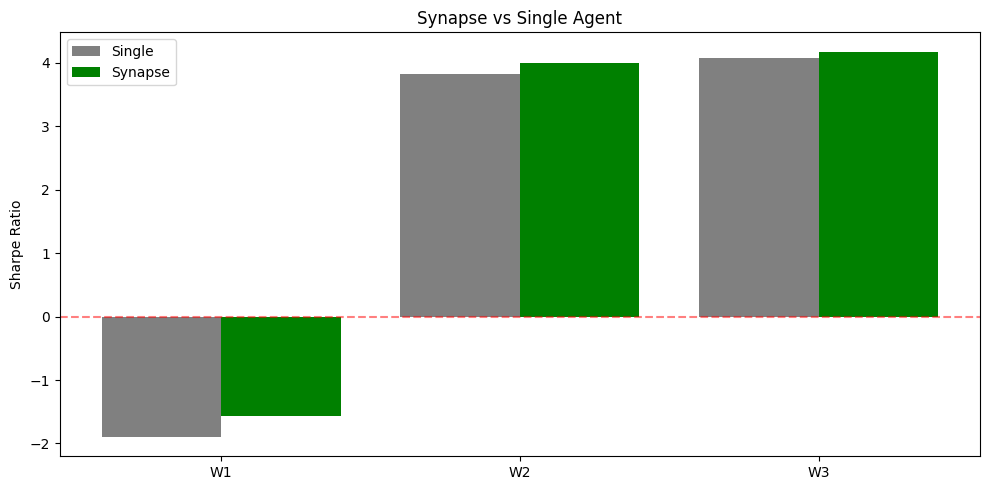


✅ Results saved to synapse_results.csv


In [8]:
# Cell 8: Results Summary
import matplotlib.pyplot as plt

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

print(f"\nAverage Single Sharpe:  {results_df['single_sharpe'].mean():.3f}")
print(f"Average Synapse Sharpe: {results_df['synapse_sharpe'].mean():.3f}")
print(f"Improvement: {results_df['synapse_sharpe'].mean() - results_df['single_sharpe'].mean():+.3f}")

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(results_df))
ax.bar([i-0.2 for i in x], results_df['single_sharpe'], 0.4, label='Single', color='gray')
ax.bar([i+0.2 for i in x], results_df['synapse_sharpe'], 0.4, label='Synapse', color='green')
ax.set_xticks(x); ax.set_xticklabels(results_df['window'])
ax.set_ylabel('Sharpe Ratio'); ax.legend(); ax.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.title('Synapse vs Single Agent'); plt.tight_layout(); plt.show()

results_df.to_csv('synapse_results.csv', index=False)
print("\n✅ Results saved to synapse_results.csv")